# Exploration

Dieses Notebook ist fuer erste Analysen der Rohdaten und Feature-Daten gedacht.

In [3]:
from pathlib import Path
import pandas as pd
import sns

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
raw_path = "C:/Users/keith/OneDrive/Dokumente/HTW/Untersoftware/v2/dataScienceProject/tech_stock_prediction/experiments/exp_1_1/data/raw/tech_stocks_raw.csv"
features_path = "project_root / 'data' / 'processed' / 'tech_stocks_features.csv'"

raw_path, features_path

('C:/Users/keith/OneDrive/Dokumente/HTW/Untersoftware/v2/dataScienceProject/tech_stock_prediction/experiments/exp_1_1/data/raw/tech_stocks_raw.csv',
 "project_root / 'data' / 'processed' / 'tech_stocks_features.csv'")

In [4]:
raw_data = pd.read_csv(raw_path, parse_dates=['Date'])
raw_data.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2019-01-02,37.469208,39.480000,39.712502,38.557499,38.722500,148158800,AAPL
1,2019-01-02,224.570007,224.570007,226.169998,219.000000,219.910004,2784100,ADBE
2,2019-01-02,18.830000,18.830000,19.000000,17.980000,18.010000,87148700,AMD
3,2019-01-02,76.956497,76.956497,77.667999,73.046501,73.260002,159662000,AMZN
4,2019-01-02,52.301731,52.734001,53.039501,51.264000,51.360001,31868000,GOOGL


In [5]:
raw_data.groupby('Ticker')['Close'].describe()

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,1863.0,157.134179,65.052610,35.547501,119.325001,157.869995,200.925003,312.510010
ADBE,1863.0,422.196146,112.237270,215.699997,333.629990,417.209991,504.784988,688.369995
AMD,1863.0,109.587880,65.720023,17.049999,72.579998,98.120003,140.809998,518.090027
AMZN,1863.0,153.353231,47.642097,75.014000,108.221748,156.510498,184.077003,274.989990
GOOGL,1863.0,135.181917,70.816088,51.273499,85.940250,123.529999,162.744995,402.619995
INTC,1863.0,42.980561,15.326169,18.129999,30.625000,44.860001,52.955000,129.440002
META,1863.0,353.093221,186.896622,88.910004,196.075005,294.470001,508.300003,790.000000
MSFT,1863.0,301.673819,114.197430,97.400002,214.614998,289.980011,406.735001,542.070007
NVDA,1863.0,57.859041,63.238634,3.199750,12.850875,22.698000,110.639999,235.740005


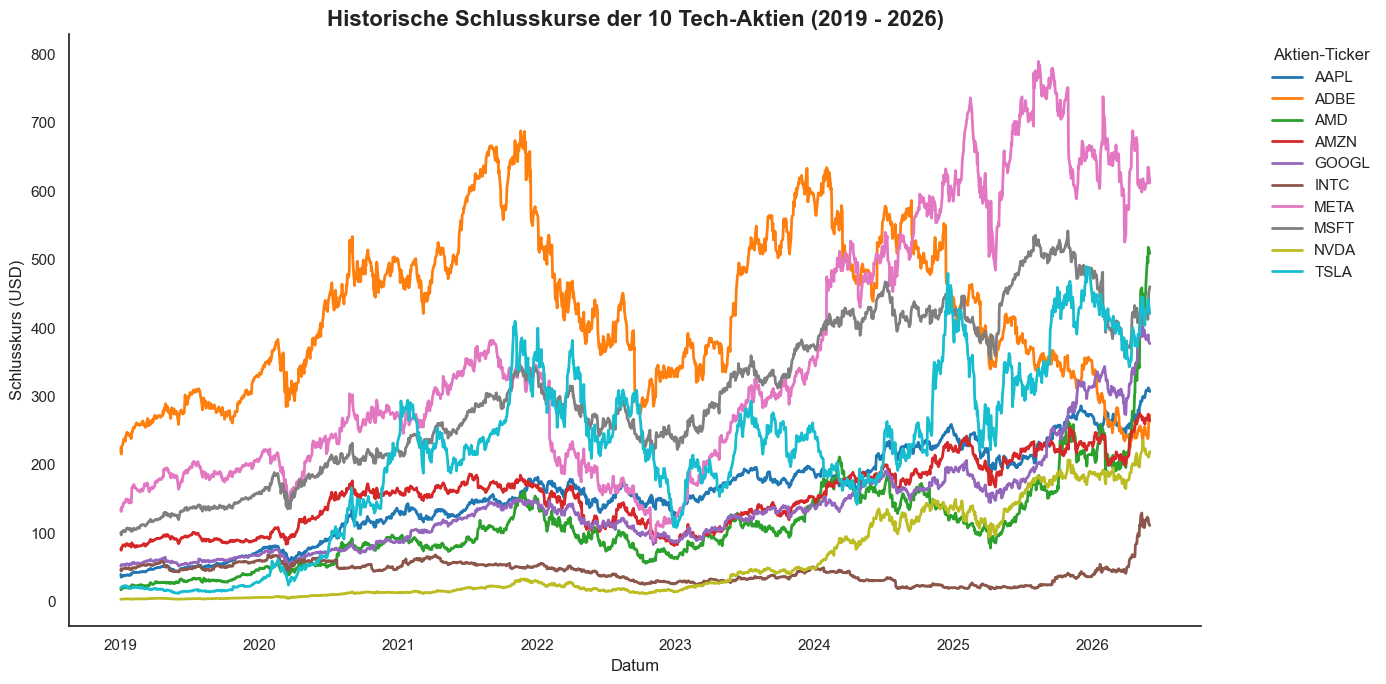

In [6]:

# Rohdaten - nicht unsere Daten
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wir schalten das Gitter komplett ab für einen absolut reinen, weißen Hintergrund
sns.set_theme(style="white")

# 2. Erstellen der Figur mit rein weißem Hintergrund für die gesamte Grafik
plt.figure(figsize=(14, 7), facecolor='white')

# 3. Linien plotten mit einer sehr klaren, kontrastreichen Farbpalette
# 'tab10' sorgt dafür, dass sich die 10 Aktien farblich perfekt voneinander abheben
ax = sns.lineplot(
    data=raw_data,
    x='Date',
    y='Close',
    hue='Ticker',
    palette='tab10',
    linewidth=2.0
)

# 4. Titel und Beschriftungen in einem gut lesbaren Dunkelgrau
plt.title('Historische Schlusskurse der 10 Tech-Aktien (2019 - 2026)', fontsize=16, fontweight='bold', color='#222222')
plt.xlabel('Datum', fontsize=12, color='#222222')
plt.ylabel('Schlusskurs (USD)', fontsize=12, color='#222222')

# 5. Legende perfekt auf weißem Hintergrund platzieren
plt.legend(title='Aktien-Ticker', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# 6. Unnötige schwarze Rahmenlinien oben und rechts entfernen (wirkt noch offener und heller)
sns.despine()

plt.tight_layout()
plt.show()

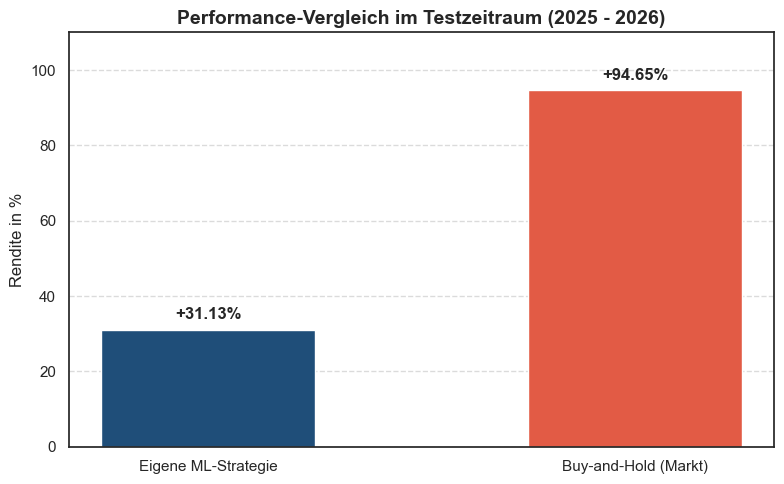

In [11]:
import matplotlib.pyplot as plt
# Gewinne nach unseren Modell vs. Tatsächlichen Gewinn
# Echte Ergebnisse aus eurem Terminal-Durchlauf eintragen
ergebnisse = {
    'Eigene ML-Strategie': 31.13,
    'Buy-and-Hold (Markt)': 94.65
}

# Diagramm erstellen
plt.figure(figsize=(8, 5))
farben = ['#1F4E79', '#E25B45'] # Blau für euch, Rot für den Markt

bars = plt.bar(ergebnisse.keys(), ergebnisse.values(), color=farben, width=0.5)

# Prozentzahlen oben auf die Balken schreiben
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"+{yval}%", ha='center', va='bottom', fontweight='bold')

plt.title('Performance-Vergleich im Testzeitraum (2025 - 2026)', fontsize=14, fontweight='bold')
plt.ylabel('Rendite in %', fontsize=12)
plt.ylim(0, 110) # Platz nach oben lassen für die Beschriftung
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

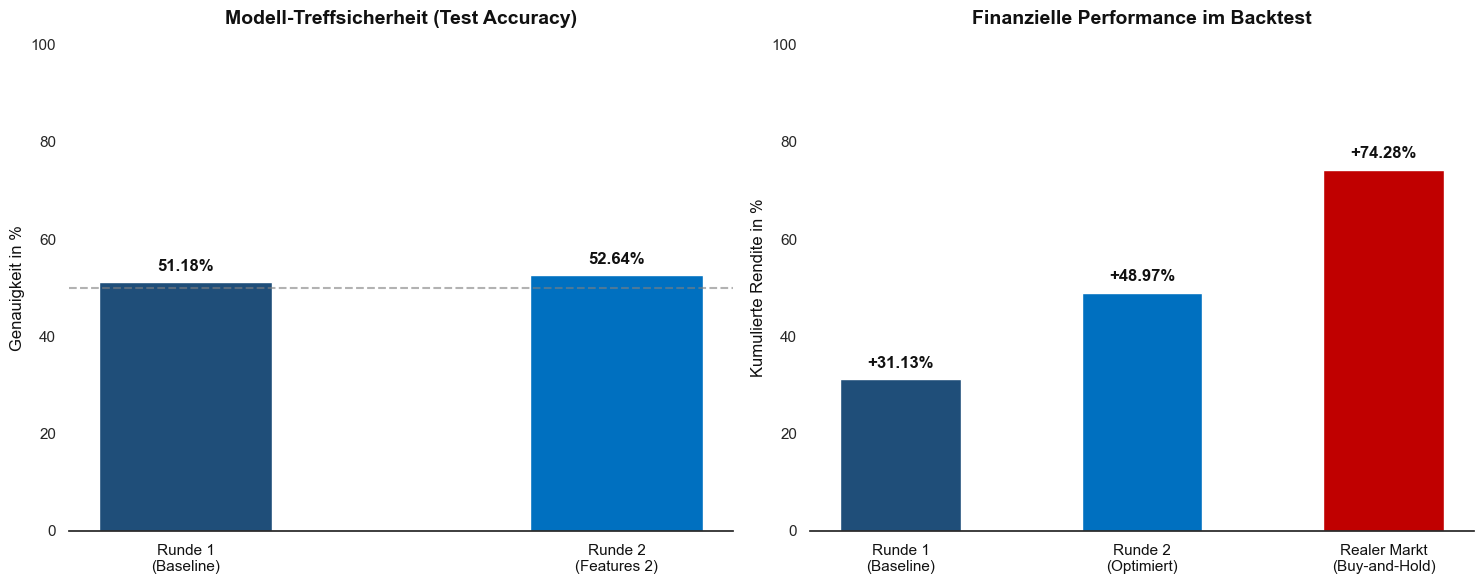

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

accuracy_runde1 = 51.18
rendite_runde1 = 31.13

accuracy_runde2 = 52.64
rendite_runde2 = 48.97

rendite_markt = 74.28

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')

labels_acc = ['Runde 1\n(Baseline)', 'Runde 2\n(Features 2)']
values_acc = [accuracy_runde1, accuracy_runde2]

kraeftige_farben_acc = ['#1F4E79', '#0070C0']
bars1 = ax1.bar(labels_acc, values_acc, color=kraeftige_farben_acc, width=0.4)

ax1.set_title('Modell-Treffsicherheit (Test Accuracy)', fontsize=14, fontweight='bold', pad=15, color='#111111')
ax1.set_ylabel('Genauigkeit in %', fontsize=12, color='#111111')
ax1.set_ylim(0, 100)
ax1.axhline(50, color='gray', linestyle='--', alpha=0.6)

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 6), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=12, color='#111111')

labels_ret = ['Runde 1\n(Baseline)', 'Runde 2\n(Optimiert)', 'Realer Markt\n(Buy-and-Hold)']
values_ret = [rendite_runde1, rendite_runde2, rendite_markt]

kraeftige_farben_ret = ['#1F4E79', '#0070C0', '#C00000']
bars2 = ax2.bar(labels_ret, values_ret, color=kraeftige_farben_ret, width=0.5)

ax2.set_title('Finanzielle Performance im Backtest', fontsize=14, fontweight='bold', pad=15, color='#111111')
ax2.set_ylabel('Kumulierte Rendite in %', fontsize=12, color='#111111')
ax2.set_ylim(0, 100)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'+{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 6), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=12, color='#111111')

sns.despine(left=True, top=True, right=True)

ax1.tick_params(axis='x', labelsize=11, labelcolor='#111111')
ax2.tick_params(axis='x', labelsize=11, labelcolor='#111111')

plt.tight_layout()
plt.show()